# Notebook 9: Swin Transformer — Beyond CNNs

**Goal:** Apply a Vision Transformer to CIFAR-10, showing a fundamentally different
approach to image classification that doesn't use convolutions.

**Swin Transformer** (Shifted Window) uses self-attention to process images:
- Divides images into non-overlapping patches
- Applies self-attention within local windows
- Shifts windows between layers to capture cross-window connections
- Creates hierarchical feature maps (like a CNN) but using attention

**CNN vs Transformer:**
- CNN: Learns local patterns via sliding filters (convolutions)
- Transformer: Learns global relationships via self-attention

---

## 9.1 Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

from src.data_utils import CIFAR10_CLASSES, CIFAR10_MEAN, CIFAR10_STD, get_raw_cifar10
from src.models import count_parameters
from src.train import train_model, evaluate, evaluate_with_probs
from src.visualize import (plot_training_curves, plot_confusion_matrix,
                           plot_per_class_accuracy, plot_misclassified, plot_roc_curves)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 9.2 Data — Resize to 224×224 for Swin

Swin Transformer expects 224×224 input images (designed for ImageNet).
We resize our 32×32 CIFAR-10 images up to 224×224.

This is a trade-off: upscaling adds no new information, but it allows us
to use the standard Swin architecture without modification.

In [2]:
import torchvision
from torch.utils.data import DataLoader

# Transforms with resize to 224x224
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=28),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

train_dataset = torchvision.datasets.CIFAR10(
    root='../data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='../data', train=False, download=True, transform=transform_test
)

# Smaller batch size — Swin is memory-hungry with 224x224 input
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=0, pin_memory=True)

print(f"Training batches: {len(train_loader)} (batch_size=32)")
print(f"Test batches: {len(test_loader)}")
print(f"Image size: 224×224 (resized from 32×32)")

c:\Users\Prithvi Nair\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training batches: 1563 (batch_size=32)
Test batches: 313
Image size: 224×224 (resized from 32×32)


## 9.3 Model Architecture

In [3]:
# Swin-Tiny: the smallest Swin variant
model = models.swin_t(weights=None)  # Train from scratch for fair comparison

# Replace the classification head for 10 classes (default is 1000 for ImageNet)
model.head = nn.Linear(model.head.in_features, 10)

n_params = count_parameters(model)
print(f"Swin-Tiny trainable parameters: {n_params:,}")
print(f"SimpleCNN: 2,168,746")
print(f"ResNet-18: ~11M")
print(f"Swin-T is {n_params / 2_168_746:.1f}x larger than SimpleCNN")

Swin-Tiny trainable parameters: 27,527,044
SimpleCNN: 2,168,746
ResNet-18: ~11M
Swin-T is 12.7x larger than SimpleCNN


## 9.4 Training

We use cosine annealing LR since transformers benefit from smooth LR decay.

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)  # Lower LR for transformers
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=30,
    lr=0.0001,
    device=device,
    optimizer=optimizer,
    scheduler=scheduler
)

Training on: cuda
Epochs: 30, Learning Rate: 0.0001
Model parameters: 27,527,044
------------------------------------------------------------
Epoch   1/30 | Train Loss: 1.8119 | Train Acc: 32.7% | Test Loss: 1.5328 | Test Acc: 44.6% | Time: 835.8s
Epoch   5/30 | Train Loss: 1.0396 | Train Acc: 62.7% | Test Loss: 0.9789 | Test Acc: 64.6% | Time: 952.7s
Epoch  10/30 | Train Loss: 0.7708 | Train Acc: 72.7% | Test Loss: 0.7805 | Test Acc: 72.5% | Time: 831.8s
Epoch  15/30 | Train Loss: 0.5955 | Train Acc: 78.9% | Test Loss: 0.6087 | Test Acc: 79.0% | Time: 1004.9s
Epoch  20/30 | Train Loss: 0.4723 | Train Acc: 83.4% | Test Loss: 0.5252 | Test Acc: 81.9% | Time: 851.1s
Epoch  25/30 | Train Loss: 0.3837 | Train Acc: 86.6% | Test Loss: 0.4816 | Test Acc: 84.3% | Time: 880.2s
Epoch  30/30 | Train Loss: 0.3550 | Train Acc: 87.5% | Test Loss: 0.4687 | Test Acc: 84.5% | Time: 879.2s
------------------------------------------------------------
Best test accuracy: 84.5%
Total training time: 27071s 

In [5]:
torch.save(model.state_dict(), '../saved_models/swin_transformer.pth')
print("Model saved to saved_models/swin_transformer.pth")

Model saved to saved_models/swin_transformer.pth


## 9.5 Training Curves

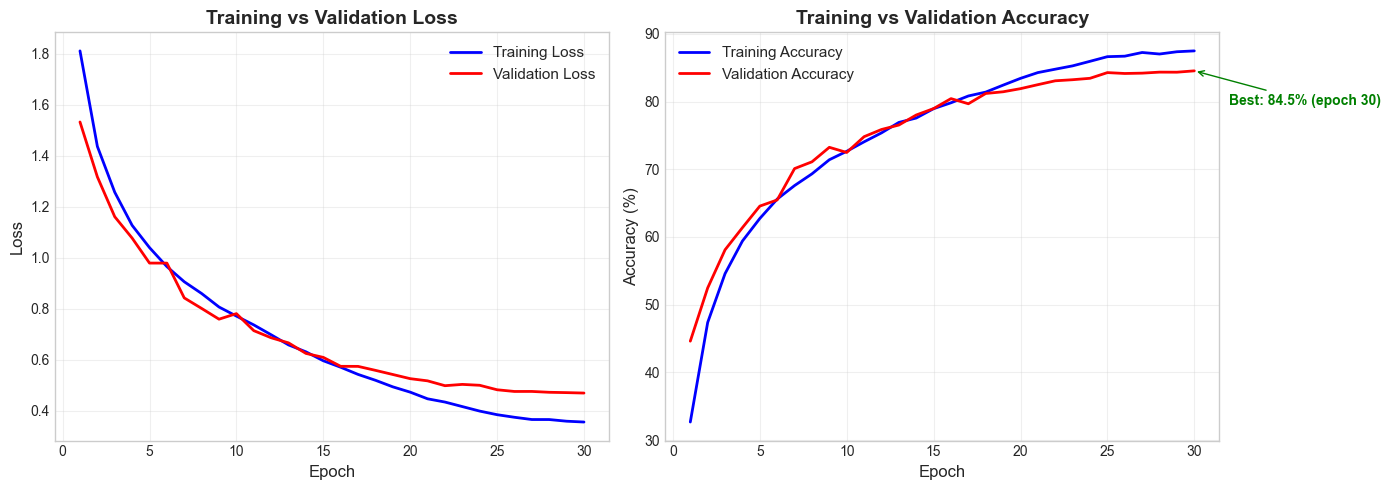

In [6]:
fig = plot_training_curves(history)
plt.show()

## 9.6 Test Set Evaluation

In [7]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, predictions, true_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"Final Test Results:")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")

Final Test Results:
  Test Loss:     0.4687
  Test Accuracy: 84.53%


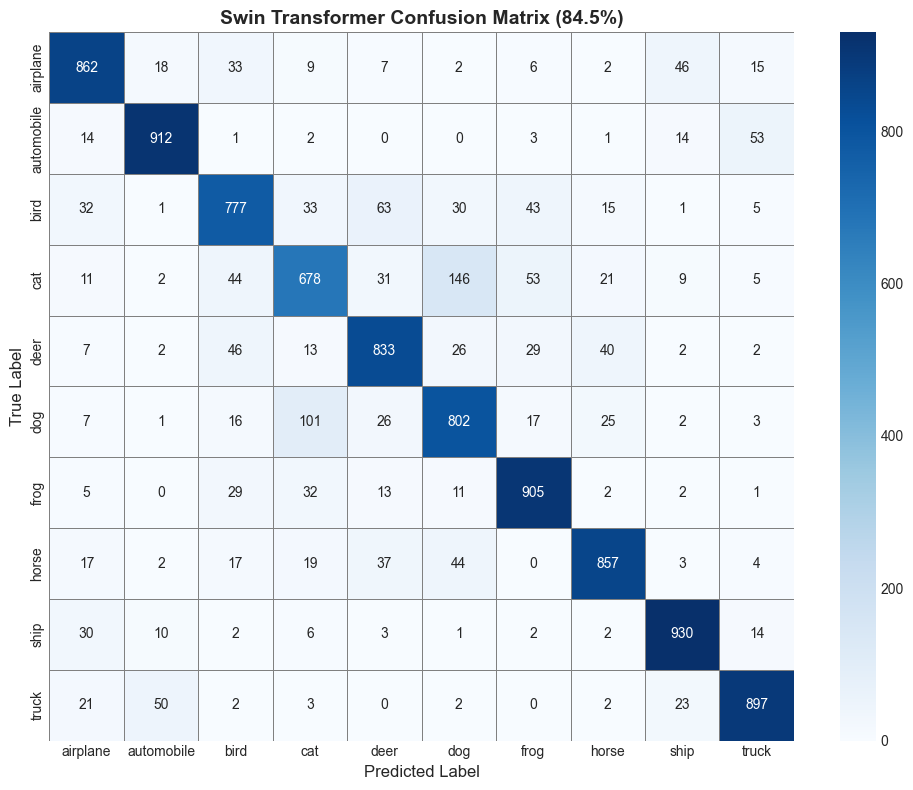

In [8]:
fig = plot_confusion_matrix(
    true_labels, predictions, CIFAR10_CLASSES,
    title=f'Swin Transformer Confusion Matrix ({test_acc:.1f}%)'
)
plt.show()

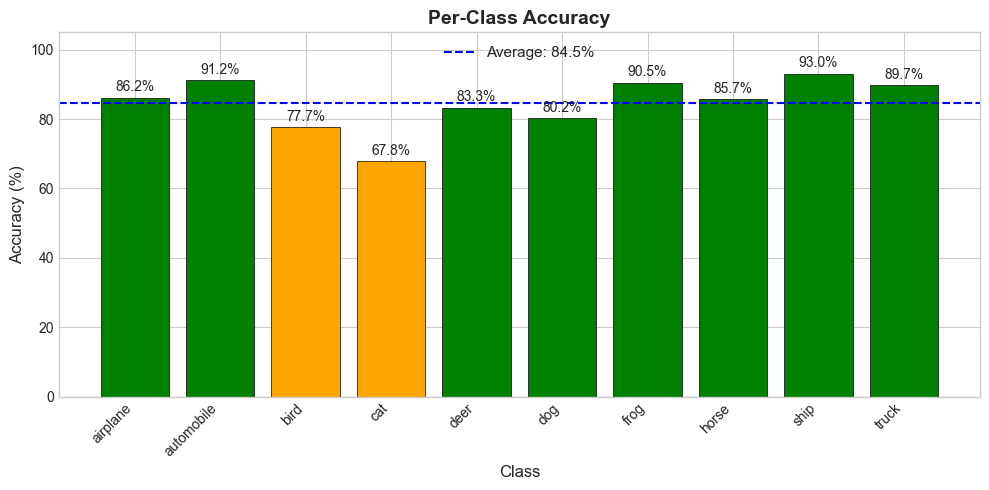

In [9]:
fig = plot_per_class_accuracy(true_labels, predictions, CIFAR10_CLASSES)
plt.show()

c:\Users\Prithvi Nair\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


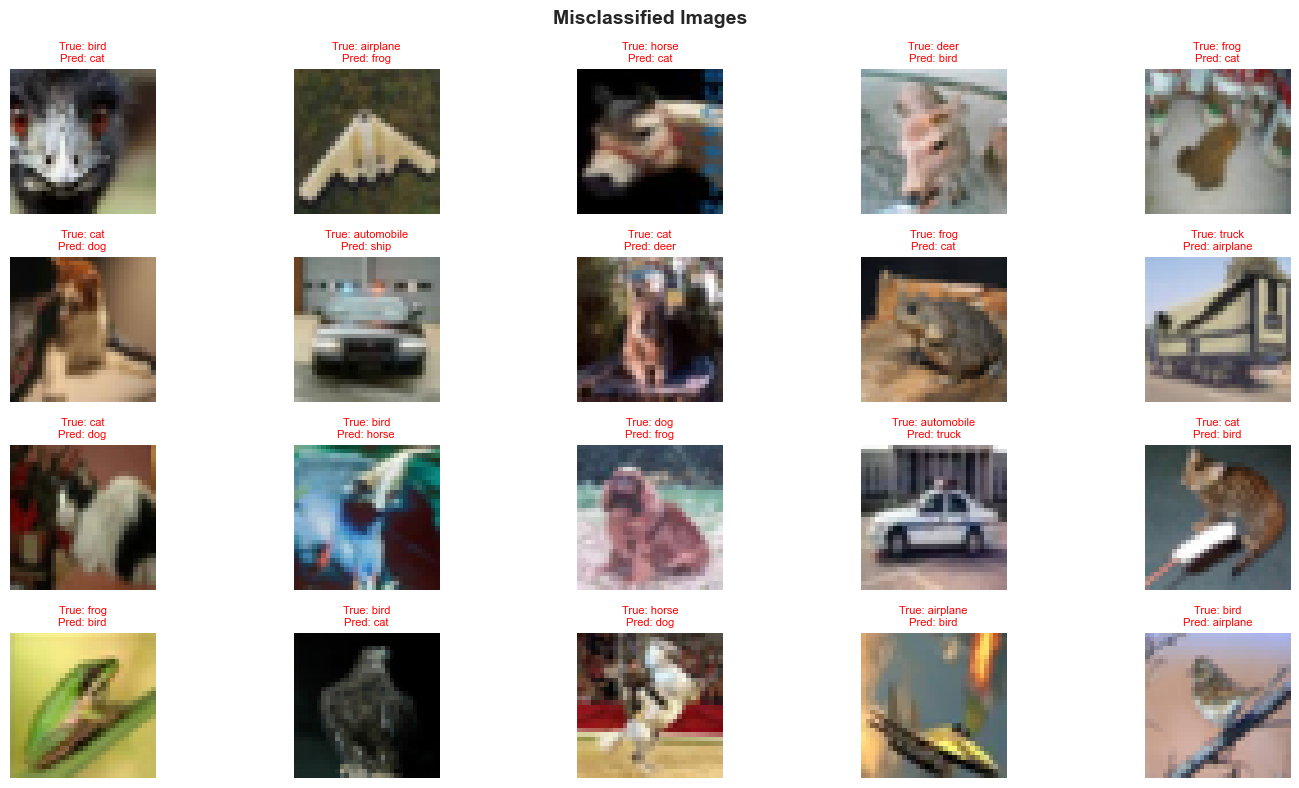

In [10]:
_, raw_test = get_raw_cifar10(data_dir='../data')
test_images = [np.array(raw_test[i][0]) for i in range(len(raw_test))]

fig = plot_misclassified(test_images, true_labels, predictions, CIFAR10_CLASSES, n=20)
plt.show()

## 9.7 ROC Curves

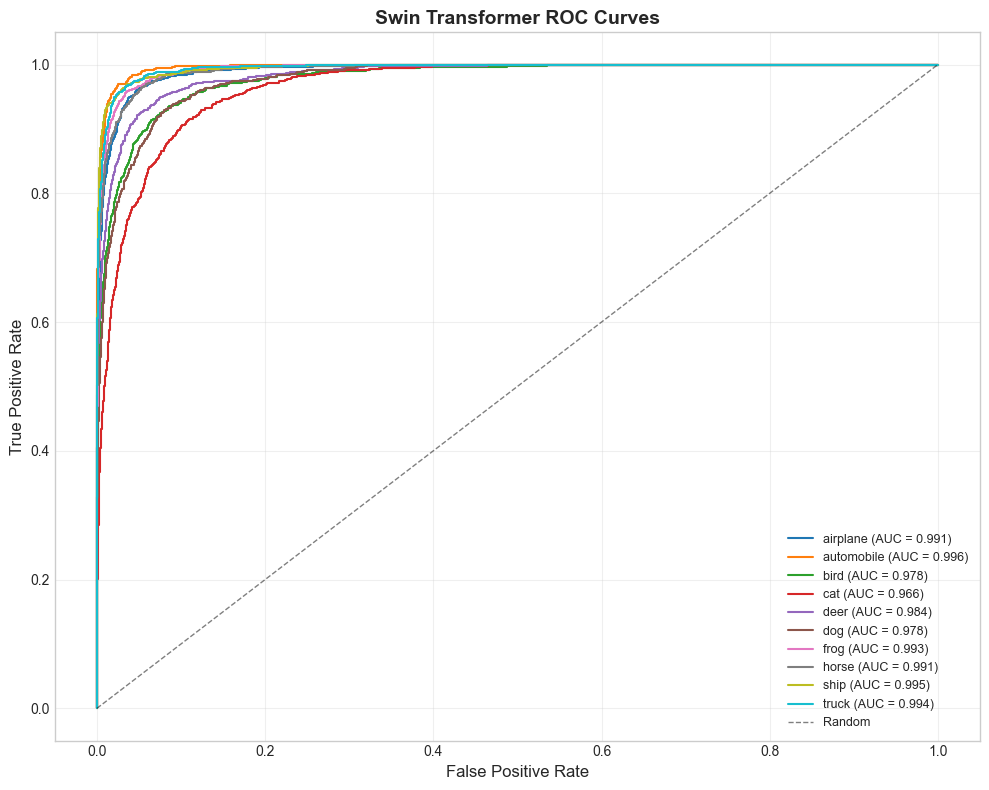

In [11]:
accuracy, preds, labels, probabilities = evaluate_with_probs(model, test_loader, device)

fig = plot_roc_curves(labels, probabilities, CIFAR10_CLASSES,
                      title='Swin Transformer ROC Curves')
plt.show()

## 9.8 Save Results

In [12]:
import json

swin_results = {
    'accuracy': test_acc,
    'total_time': sum(history['epoch_times']),
    'epochs': len(history['train_loss']),
    'predictions': predictions,
    'true_labels': true_labels,
    'probabilities': probabilities.tolist(),
    'history': {
        'train_loss': history['train_loss'],
        'train_acc': history['train_acc'],
        'test_loss': history['test_loss'],
        'test_acc': history['test_acc']
    },
    'n_parameters': n_params
}

with open('../saved_models/swin_results.json', 'w') as f:
    json.dump(swin_results, f)

print(f"Results saved. Test accuracy: {test_acc:.2f}%")
print(f"Training time: {sum(history['epoch_times']):.0f}s ({sum(history['epoch_times'])/60:.1f} min)")

Results saved. Test accuracy: 84.53%
Training time: 27071s (451.2 min)


## 9.9 Summary

### Swin Transformer — A non-CNN approach:
- **Architecture:** Self-attention with shifted windows (no convolutions)
- **Parameters:** ~28M (largest model in our comparison)
- **Input:** 224×224 (resized from 32×32)
- **Key insight:** Transformers can match or exceed CNNs on vision tasks
- **Trade-off:** More parameters, more memory, slower training — but captures global relationships that CNNs miss